
Predicted probabilities (first 20 patients) with true diagnosis:
    Patient  True Diagnosis  Logistic Regression (%)  Random Forest (%)  \
0         1               1                    79.31              78.96   
1         2               0                     0.30               1.16   
2         3               0                     0.30               4.07   
3         4               0                     5.63              13.09   
4         5               0                     0.00               0.18   
5         6               0                    58.51              65.57   
6         7               0                    21.99              28.99   
7         8               0                    17.32              18.73   
8         9               0                     1.68               2.32   
9        10               0                    17.63              19.26   
10       11               0                     1.02               3.14   
11       12               0       

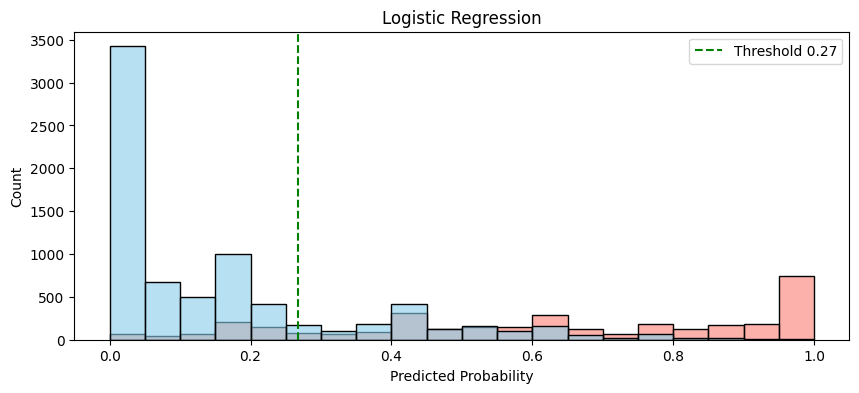

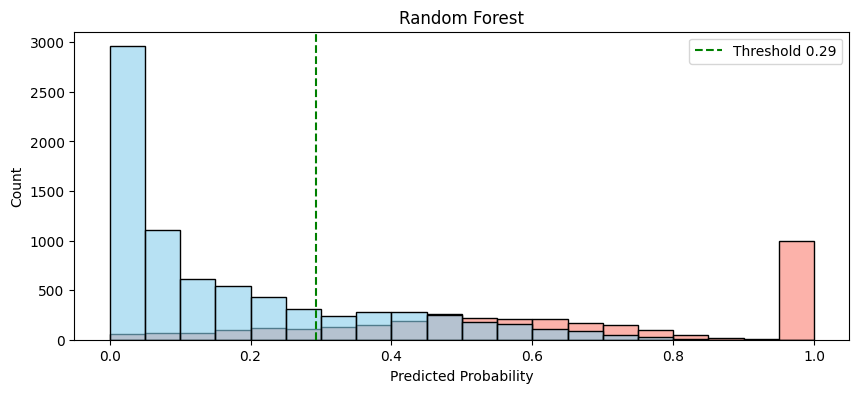

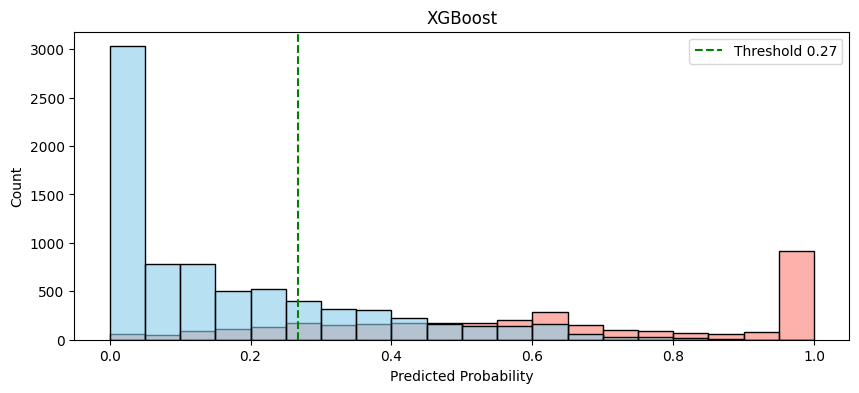


Logistic Regression Metrics (threshold=0.27):
Accuracy: 0.807
Precision: 0.643
Recall: 0.838
F1-score: 0.728
ROC AUC: 0.905
Brier Score: 0.111
Classification Report:
              precision    recall  f1-score   support

           0      0.917     0.793     0.851      7618
           1      0.643     0.838     0.728      3382

    accuracy                          0.807     11000
   macro avg      0.780     0.816     0.789     11000
weighted avg      0.833     0.807     0.813     11000


Random Forest Metrics (threshold=0.29):
Accuracy: 0.800
Precision: 0.629
Recall: 0.849
F1-score: 0.723
ROC AUC: 0.899
Brier Score: 0.114
Classification Report:
              precision    recall  f1-score   support

           0      0.921     0.778     0.843      7618
           1      0.629     0.849     0.723      3382

    accuracy                          0.800     11000
   macro avg      0.775     0.813     0.783     11000
weighted avg      0.831     0.800     0.806     11000


XGBoost Metrics (

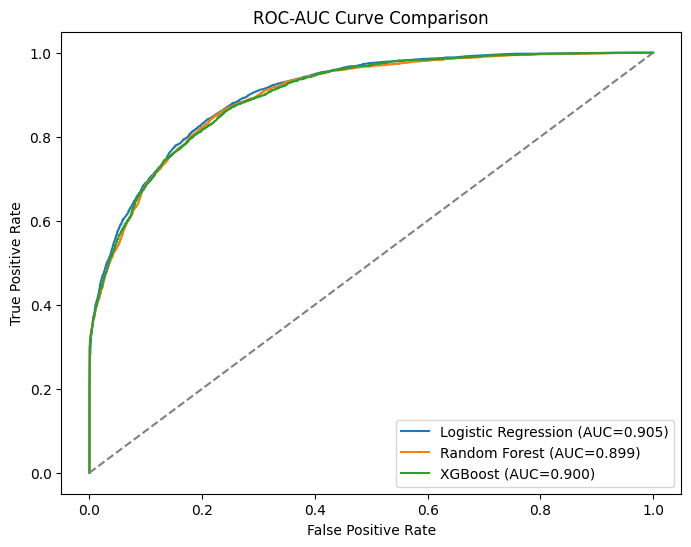

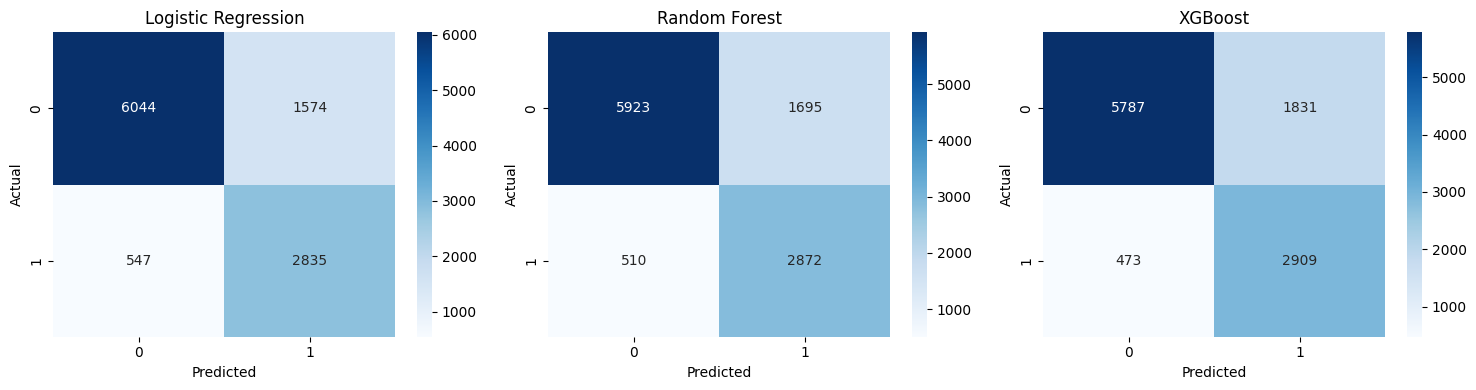

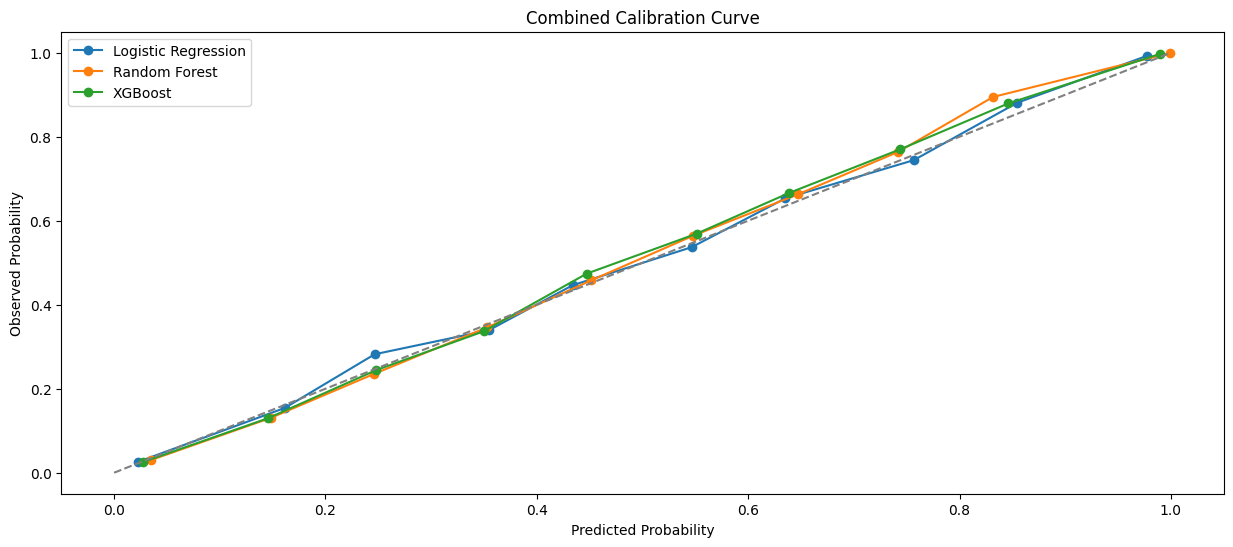

Random Forest model saved as predictive_model.pkl


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

# Load and prepare training data
train_data = pd.read_csv("training_dataset.csv")
X_train = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_train = train_data["Diagnosed"]
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Load and prepare test data
test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

# Identify feature types
numeric_features = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

# Create model pipelines
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", l1_ratio=0.5, C=1.0))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42))
])

# Calibrate models
logreg_model = CalibratedClassifierCV(logreg_pipeline, method="isotonic", cv=5)
rf_model = CalibratedClassifierCV(rf_pipeline, method="isotonic", cv=5)
xgb_model = CalibratedClassifierCV(xgb_pipeline, method="isotonic", cv=5)

# Train models
logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)


# Get predicted probabilities
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Show first 20 predictions
print("\nPredicted probabilities (first 20 patients) with true diagnosis:")
df_probs = pd.DataFrame({
    "Patient": range(1, 21),
    "True Diagnosis": y_test.iloc[:20].values,
    "Logistic Regression (%)": np.round(logreg_prob[:20]*100, 2),
    "Random Forest (%)": np.round(rf_prob[:20]*100, 2),
    "XGBoost (%)": np.round(xgb_prob[:20]*100, 2)
})
print(df_probs)

# Find optimal thresholds
def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

logreg_threshold = find_best_threshold(y_test, logreg_prob)
rf_threshold = find_best_threshold(y_test, rf_prob)
xgb_threshold = find_best_threshold(y_test, xgb_prob)

# Plot probability distributions
def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x="Probability", hue="Diagnosis", bins=20, palette=["skyblue", "salmon"], alpha=0.6)
    plt.axvline(threshold, color="green", linestyle="--", label=f"Threshold {threshold:.2f}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(name)
    plt.legend()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_prob, rf_threshold, "Random Forest")
plot_probabilities_horizontal(y_test, xgb_prob, xgb_threshold, "XGBoost")

# Plot feature importance
def plot_feature_importance(pipeline_model, name):
    classifier = pipeline_model.named_steps["classifier"]
    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        feature_names_tree = list(preprocessor.transformers_[0][2]) + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
        indices = np.argsort(importances)[-15:]
        plt.figure(figsize=(8, 5))
        plt.barh(range(len(indices)), importances[indices])
        plt.yticks(range(len(indices)), [feature_names_tree[i] for i in indices])
        plt.title(name + " Feature Importance")
        plt.show()

plot_feature_importance(rf_pipeline, "Random Forest")
plot_feature_importance(xgb_pipeline, "XGBoost")

# Evaluate models
def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    
    print(f"\n{name} Metrics (threshold={threshold:.2f}):")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"ROC AUC: {roc_auc:.3f}")
    print(f"Brier Score: {brier:.3f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=3))
    
    cm = confusion_matrix(y_true, y_pred)
    return cm

logreg_cm = evaluate_model(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
rf_cm = evaluate_model(y_test, rf_prob, rf_threshold, "Random Forest")
xgb_cm = evaluate_model(y_test, xgb_prob, xgb_threshold, "XGBoost")

# Plot ROC curves
plt.figure(figsize=(8,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.show()

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(logreg_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Logistic Regression")

sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Random Forest")

sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()

# Plot calibration curves
plt.figure(figsize=(15,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Combined Calibration Curve")
plt.legend()
plt.show()

# Save Random Forest model
joblib.dump(rf_model, 'predictive_model.pkl', compress=3)
print("Random Forest model saved as predictive_model.pkl")